In [1]:
import sys

sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from python.data_generation import SyntheticDataGenerator
from python.distances import TwoUTASpaceDiameter

In [3]:
generator = SyntheticDataGenerator(
    n_dms=2,
    n_criteria=4,
    method_params={"n_pieces": 5},
    gap=0.001,
    decimals=3
)

# X, Y, info = generator.generate_indifferences(num_pairs=600, return_clusters=True)

In [31]:
X, Y, info = generator.generate_preferences_all_dms(num_pairs=5_000, return_clusters=True, return_utilities=True)

X_0 = X[np.arange(0, len(X), 2)]
Y_0 = Y[np.arange(0, len(X), 2)]

In [ ]:
dist_decoupled = TwoUTASpaceDiameter(n_pieces=5, epsilon=1e-3, lipschitz_coeff=1e-4)
# dist.solver.setParam("DualReductions", 0)
dist_decoupled.fit_generic(X[:4_00], Y[:4_00], time_limit=60, inflexions=np.vstack([np.linspace(0, 1., 6)] * 4), relation_type="preference")

In [59]:
dist_decoupled.solver.ObjVal

9.847188996708748

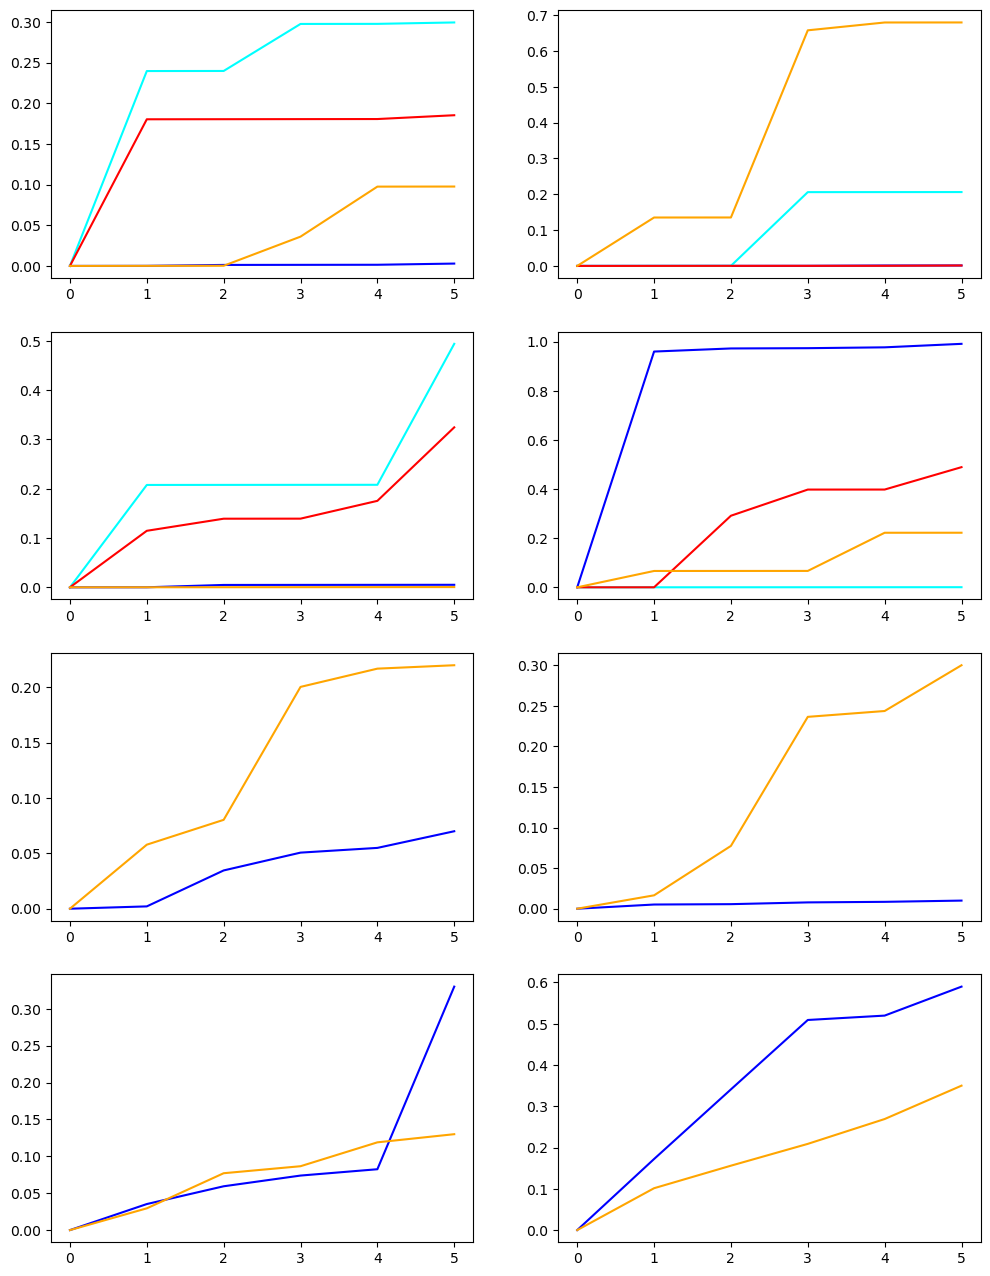

In [61]:
plt.figure(figsize=(12, 16))
for i in range(4):
    plt.subplot(4, 2, i+1)
    plt.plot([dist_decoupled.marginal_coeffs["s1", i, k].x for k in range(6)], c="blue")
    plt.plot([dist_decoupled.marginal_coeffs["s2", i, k].x for k in range(6)], c="cyan")
    plt.plot([dist_decoupled.marginal_coeffs["d1", i, k].x for k in range(6)], c="red")
    plt.plot([dist_decoupled.marginal_coeffs["d2", i, k].x for k in range(6)], c="orange")

for i in range(4):
    plt.subplot(4, 2, i+5)
    plt.plot(generator.dms[0].coefficients[i], c="blue")
    plt.plot(generator.dms[1].coefficients[i], c="orange")


In [ ]:
for ux, uy in zip(info["utilities_x"], info["utilities_y"]):
    if (ux - uy) > 1e-10:
        print(ux, uy)
        break

In [ ]:
generator.dms[0].coefficients[0][1]

In [ ]:
np.sum(generator.dms[0].coefficients[:, -1]), np.sum(generator.dms[1].coefficients[:, -1])

In [ ]:
from python.models import UTA

In [ ]:
errors = []
epsilons = [1e-3, 1e-5, 1e-7, 1e-9]
for eps in epsilons:
    uta = UTA(n_pieces=5, epsilon=eps)
    res = uta.fit_from_indifferences(X_0, Y_0, inflexions=np.vstack([np.linspace(0, 1., 6)] * 4))
    errors.append(uta.solver.ObjVal)

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(info["coefficients_0"][i], c="blue")
    plt.plot(uta.coeffs[i], c="orange")

In [ ]:
from python.distances import TwoUTASpaceDiameter
from python.sub_distances import SubTwoUTASpaceDiameter

dist = TwoUTASpaceDiameter(n_pieces=5, epsilon=1e-3)
# dist.solver.setParam("DualReductions", 0)
dist.fit_from_coupled_indifferences(X[:50], Y[:50], time_limit=3600, inflexions=np.vstack([np.linspace(0, 1., 6)] * 4), warm_zs=True)

In [ ]:
dist.solver.status

In [ ]:
dist_decoupled = TwoUTASpaceDiameter(n_pieces=5, epsilon=1e-3)
# dist.solver.setParam("DualReductions", 0)
dist_decoupled.fit_from_indifferences(X[:50], Y[:50], time_limit=3600, inflexions=np.vstack([np.linspace(0, 1., 6)] * 4))

In [ ]:
plt.figure(figsize=(12, 16))
for i in range(4):
    plt.subplot(4, 2, i+1)
    plt.plot([dist.marginal_coeffs["s1", i, k].x for k in range(6)], c="blue")
    plt.plot([dist.marginal_coeffs["s2", i, k].x for k in range(6)], c="cyan")
    plt.plot([dist.marginal_coeffs["d1", i, k].x for k in range(6)], c="red")
    plt.plot([dist.marginal_coeffs["d2", i, k].x for k in range(6)], c="orange")

for i in range(4):
    plt.subplot(4, 2, i+5)
    plt.plot(generator.dms[0].coefficients[i], c="blue")
    plt.plot(generator.dms[1].coefficients[i], c="orange")


In [ ]:
def fit_from_coupled_indifferences(
        mydist,
        X,
        Y,
        inflexions=None,
        sample_weight=None,
        time_limit=None,
        verbose=0,
        majoring_value=10,
        clustering=None,
        warm_coefficients=None,
        warm_zs=None,
    ):
        """Estimation of the parameters"""
        n_samples = X.shape[0]
        n_features = Y.shape[1]

        if inflexions is None:
            mydist.min, mydist.max, mydist.inflexions = mydist._determine_inflexions(X, Y)
        else:
            inflexions = np.array(inflexions)

            assert inflexions.shape[0] == n_features
            assert inflexions.shape[1] == mydist.n_pieces + 1

            mydist.min = np.min(inflexions, axis=0)
            mydist.max = np.max(inflexions, axis=0)
            mydist.inflexions = inflexions

        if clustering is not None:
            values, counts = np.unique(clusterint, return_counts=True)
            for count in counts:
                assert count == 2
        n_couples = int(n_samples // 2)
        print("N couples:", n_couples)

        if verbose == 0:
            mydist.solver.params.outputflag = 0  # mode muet

        if time_limit is not None:
            mydist.solver.setParam("TimeLimit", time_limit)

        if verbose > 1:
            print("1/ Variables Definition")
        mydist.marginal_coeffs = {    
            (name, i, j): mydist.solver.addVar(vtype=gp.GRB.CONTINUOUS, name=f"s_{name}_{i}_{j}")
            for j in range(mydist.n_pieces + 1)
            for i in range(n_features)
            for name in ["d1", "d2"]
            # for name in ["d1", "d2", "s1", "s2"]
        }
        # for k, v in mydist.marginal_coeffs.items():
        #     if k[2] > 0:
        #         mydist.solver.addConstr(v >= mydist.epsilon, name="min_pente")


        mydist.estimate_x = {
            (name, i, j): mydist.solver.addVar(
                vtype=gp.GRB.CONTINUOUS, name=f"estimate_x_{name}_{i}_{j}"
            )
            for j in range(n_features)
            for i in range(n_samples)
            for name in ["d1", "d2"]
            # for name in ["d1", "d2", "s1", "s2"]
        }
        
        mydist.estimate_y = {
            (name, i, j): mydist.solver.addVar(
                vtype=gp.GRB.CONTINUOUS, name=f"estimate_y_{name}_{i}_{j}"
            )
            for j in range(n_features)
            for i in range(n_samples)
            for name in ["d1", "d2"]
            # for name in ["d1", "d2", "s1", "s2"]
        }

        mydist.z_d = {
            k: mydist.solver.addVar(
                vtype=gp.GRB.BINARY, name=f"z_d_{k}"
            )
            for k in range(n_couples)
        }

        if warm_coefficients is not None:
            for key, val in mydist.marginal_coeffs.items():
                setattr(val, "Start", warm_coefficients[key])
                mydist.solver.addConstr(val == warm_coefficients[key])
                
        # dist.z_d = {
        #     k: dist.solver.addVar(
        #         vtype=gp.GRB.BINARY, name=f"z_d_{k}"
        #     )
        #     for k in range(n_couples)
        # }
        if warm_zs is not None:
            for val in mydist.z_d.values():
                setattr(val, "Start", 0)
                mydist.solver.addConstr(val == 0)
            # for val in dist.z_d.values():
            #     setattr(val, "Start", 0)
        if verbose > 1:
            print("2/ Constraints Definition")
        # [MI - 2]
        # for name in ["d1", "d2", "s1", "s2"]:
        for name in ["d1", "d2"]:
            zero_bound = {
                i: mydist.solver.addConstr(
                    mydist.marginal_coeffs[name, i, 0] == 0, name="lower_bound_normalization"
                )
                for i in range(n_features)
            }
            sum_to_one = {
                mydist.solver.addConstr(
                    (
                        gp.quicksum(
                            mydist.marginal_coeffs[name, i, mydist.n_pieces] for i in range(n_features)
                        )
                    )
                    == 1,
                    name="sum_to_one",
                )
            }
            monotonicity = {
                (i): {
                    k: mydist.solver.addConstr(
                        mydist.marginal_coeffs[name, i, k + 1] >= mydist.marginal_coeffs[name, i, k],
                        name="monotonicity",
                    )
                    for k in range(mydist.n_pieces)
                }
                for i in range(n_features)
            }
            # [MI - 4]
            # [MI - 1']
            # [MI - 8']
            if verbose > 1:
                print("3/ Utility Constraints")
            # Contraintes de préférences

            for i in range(n_samples):
                for j in range(n_features):
                    for k in range(mydist.n_pieces):
                        if mydist.inflexions[j][k] <= X[i][j] <= mydist.inflexions[j][k + 1]:
                            mydist.solver.addConstr(
                                mydist.estimate_x[name, i, j]
                                == mydist.marginal_coeffs[name, j, k]
                                + (
                                    (X[i][j] - mydist.inflexions[j][k])
                                    / (mydist.inflexions[j][k + 1] - mydist.inflexions[j][k])
                                )
                                * (mydist.marginal_coeffs[name, j, k + 1] - mydist.marginal_coeffs[name, j, k]),
                                name=f"estimate_x_{i}_{j}",
                            )
                        if mydist.inflexions[j][k] <= Y[i][j] <= mydist.inflexions[j][k + 1]:
                            mydist.solver.addConstr(
                                mydist.estimate_y[name, i, j]
                                == mydist.marginal_coeffs[name, j, k]
                                + (
                                    (Y[i][j] - mydist.inflexions[j][k])
                                    / (mydist.inflexions[j][k + 1] - mydist.inflexions[j][k])
                                )
                                * (mydist.marginal_coeffs[name, j, k + 1] - mydist.marginal_coeffs[name, j, k]),
                                name=f"estimate_y_{i}_{j}",
                            )
            
        mydist.pref_d1 = {}
        mydist.pref_d1_prime = {}
        mydist.pref_d2 = {}
        mydist.pref_d2_prime = {}
        mydist.pref_s1 = {}
        mydist.pref_s1_prime = {}
        mydist.pref_s2 = {}
        mydist.pref_s2_prime = {}
        mydist.solver.addConstr(mydist.z_d[0] == 0)
        for i in range(n_samples):
            if i % 2 == 0:
                mydist.pref_d1["d1", i] = mydist.solver.addConstr(
                    gp.quicksum([mydist.estimate_x[("d1", i, j)] for j in range(n_features)])
                    - gp.quicksum([mydist.estimate_y[("d1", i, j)] for j in range(n_features)])
                    - majoring_value * mydist.z_d[i // 2]
                    <= mydist.epsilon, name=f"d1_pref_{i}"
                )
                mydist.pref_d1_prime ["d1", i] = mydist.solver.addConstr(
                        gp.quicksum([mydist.estimate_y[("d1", i, j)] for j in range(n_features)])
                        - gp.quicksum([mydist.estimate_x[("d1", i, j)] for j in range(n_features)])
                        - majoring_value * mydist.z_d[i // 2]
                        <= mydist.epsilon, name=f"d1_pref_{i}_"
                    )

                mydist.pref_d2["d2", i] = mydist.solver.addConstr(
                        gp.quicksum([mydist.estimate_x[("d2", i, j)] for j in range(n_features)])
                        - gp.quicksum([mydist.estimate_y[("d2", i, j)] for j in range(n_features)])
                        - majoring_value * (1 - mydist.z_d[i // 2])
                        <= mydist.epsilon, name=f"d2_pref_{i}"
                    )
                mydist.pref_d2_prime["d2", i] = mydist.solver.addConstr(
                        gp.quicksum([mydist.estimate_y[("d2", i, j)] for j in range(n_features)])
                        - gp.quicksum([mydist.estimate_x[("d2", i, j)] for j in range(n_features)])
                        - majoring_value * (1 - mydist.z_d[i // 2])
                        <= mydist.epsilon, name=f"d2_pref_{i}_"
                    )
            else:

                mydist.pref_d1["d1", i] = mydist.solver.addConstr(
                    gp.quicksum([mydist.estimate_x[("d1", i, j)] for j in range(n_features)])
                    - gp.quicksum([mydist.estimate_y[("d1", i, j)] for j in range(n_features)])
                    - majoring_value * (1-mydist.z_d[i // 2])
                    <= mydist.epsilon, name=f"d1_pref_{i}"
                )
                mydist.pref_d1_prime ["d1", i] = mydist.solver.addConstr(
                        gp.quicksum([mydist.estimate_y[("d1", i, j)] for j in range(n_features)])
                        - gp.quicksum([mydist.estimate_x[("d1", i, j)] for j in range(n_features)])
                        - majoring_value * (1-mydist.z_d[i // 2])
                        <= mydist.epsilon, name=f"d1_pref_{i}_"
                    )

                mydist.pref_d2["d2", i] = mydist.solver.addConstr(
                        gp.quicksum([mydist.estimate_x[("d2", i, j)] for j in range(n_features)])
                        - gp.quicksum([mydist.estimate_y[("d2", i, j)] for j in range(n_features)])
                        - majoring_value * mydist.z_d[i // 2]
                        <= mydist.epsilon, name=f"d2_pref_{i}"
                    )
                mydist.pref_d2_prime["d2", i] = mydist.solver.addConstr(
                        gp.quicksum([mydist.estimate_y[("d2", i, j)] for j in range(n_features)])
                        - gp.quicksum([mydist.estimate_x[("d2", i, j)] for j in range(n_features)])
                        - majoring_value * mydist.z_d[i // 2]
                        <= mydist.epsilon, name=f"d2_pref_{i}_"
                    )
        ### Obj

        distance = []
        for j in range(mydist.n_pieces + 1):
            for i in range(n_features):
                distance.append(mydist.marginal_coeffs["d1", i, j] - mydist.marginal_coeffs["d2", i, j])

        mydist.solver.setObjective(
            gp.quicksum(distance), gp.GRB.MAXIMIZE
        )
        mydist.solver.update()

        # -- Résolution --
        mydist.solver.optimize()
        mydist.status = mydist.solver.Status


In [ ]:
warm_coeffs = {}
for i in range(2):
    for m in range(4):
        for n in range(6): 
            warm_coeffs[f"d{i+1}", m, n] = generator.dms[i].coefficients[m, n]

In [ ]:
import gurobipy as gp

sub_dist = SubTwoUTASpaceDiameter(n_pieces=5, epsilon=1e-2)
fit_from_coupled_indifferences(
        sub_dist,
        X,
        Y,
        inflexions=np.vstack([np.linspace(0, 1., 6)] * 4),
        time_limit=600,
        warm_coefficients=warm_coeffs,
        warm_zs=True,
    )

In [ ]:
sub_dist.solver.Status

In [ ]:
for i in range(8):
    print((sum([sub_dist.estimate_x[("d2", i, j)].x for j in range(4)])
    - sum([sub_dist.estimate_y[("d2", i, j)].x for j in range(4)])
    - 0 * 2 * (1-sub_dist.z_d[i // 2].x)), (sum([sub_dist.estimate_x[("d1", i, j)].x for j in range(4)])
    - sum([sub_dist.estimate_y[("d1", i, j)].x for j in range(4)])
    - 0 * 2 * sub_dist.z_d[i // 2].x))

In [ ]:
for i in range(8):
    print((sum([sub_dist.estimate_x[("d2", i, j)].x for j in range(4)])
    - sum([sub_dist.estimate_y[("d2", i, j)].x for j in range(4)])
    - 0 * 2 * (1-sub_dist.z_d[i // 2].x)) < 1e-3, (sum([sub_dist.estimate_x[("d1", i, j)].x for j in range(4)])
    - sum([sub_dist.estimate_y[("d1", i, j)].x for j in range(4)])
    - 0 * 2 * sub_dist.z_d[i // 2].x) < 1e-3)

In [ ]:
plt.figure(figsize=(12, 16))
for i in range(4):
    plt.subplot(4, 2, i+1)
    # plt.plot([sub_dist.marginal_coeffs["s1", i, k].x for k in range(6)], c="blue")
    # plt.plot([sub_dist.marginal_coeffs["s2", i, k].x for k in range(6)], c="cyan")
    plt.plot([sub_dist.marginal_coeffs["d1", i, k].x for k in range(6)], c="red")
    plt.plot([sub_dist.marginal_coeffs["d2", i, k].x for k in range(6)], c="orange")

for i in range(4):
    plt.subplot(4, 2, i+5)
    plt.plot(generator.dms[0].coefficients[i], c="blue")
    plt.plot(generator.dms[1].coefficients[i], c="orange")


In [ ]:
sub_dist.solver.status

In [ ]:
for cstr in dist.solver.getConstrs():
    if abs(cstr.Slack) < 1e-7 and "estimate" not in cstr.ConstrName:
        print(cstr.ConstrName, cstr.Slack)

In [ ]:
print(dist.status)
print(dist.solver.ObjVal)

In [ ]:
plt.figure(figsize=(12, 16))
for i in range(4):
    plt.subplot(4, 2, i+1)
    plt.plot([dist.marginal_coeffs["s1", i, k].x for k in range(6)], c="blue")
    plt.plot([dist.marginal_coeffs["s2", i, k].x for k in range(6)], c="cyan")
    plt.plot([dist.marginal_coeffs["d1", i, k].x for k in range(6)], c="red")
    plt.plot([dist.marginal_coeffs["d2", i, k].x for k in range(6)], c="orange")

for i in range(4):
    plt.subplot(4, 2, i+5)
    plt.plot(generator.dms[0].coefficients[i], c="blue")
    plt.plot(generator.dms[1].coefficients[i], c="orange")


In [ ]:
dist.solver.ObjVal

In [ ]:
#### CHECK CONSTRAINTS
info["coefficients_0"], info["coefficients_1"]

In [ ]:
n_features = 4
n_pieces = 5

In [ ]:
for model in ["0", "1"]:
    zero_bound = {
                (model, i): info[f"coefficients_{model}"][i, 0] == 0
                for i in range(n_features)
            }
    sum_to_one = {
                model: np.sum(
                    [info[f"coefficients_{model}"][i, n_pieces] for i in range(n_features)]
                )
            == 1
    }
    monotonicity = {
        (model, i): {
            k: info[f"coefficients_{model}"][i, k + 1] >= info[f"coefficients_{model}"][i, k]
            for k in range(n_pieces)
        }
        for i in range(n_features)
    }
print(zero_bound, sum_to_one, monotonicity)
assert np.array(list(zero_bound.values())).all()
assert np.array(list(sum_to_one.values())).all()
assert np.array(list(monotonicity.values())).all()

In [ ]:
class Obj:
    def __init__(dist,):
        pass

diste = Obj()
diste.inflexions = np.vstack([np.linspace(0, 1., 6)] * 4)

In [ ]:
estimate_x = {}
estimate_y = {}
for model in ["0", "1"]:
    for i in range(len(X)):
        for j in range(n_features):
            for k in range(n_pieces):
                if dist.inflexions[j][k] <= X[i][j] <= dist.inflexions[j][k + 1]:
                    estimate_x[model, i, j] = info[f"coefficients_{model}"][j, k] + (
                            (X[i][j] - dist.inflexions[j][k])
                            / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                        ) * (info[f"coefficients_{model}"][j, k + 1] - info[f"coefficients_{model}"][j, k])
                    
                if dist.inflexions[j][k] <= Y[i][j] <= dist.inflexions[j][k + 1]:
                    estimate_y[model, i, j] = info[f"coefficients_{model}"][j, k] + (
                            (Y[i][j] - dist.inflexions[j][k])
                            / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                        ) * (info[f"coefficients_{model}"][j, k + 1] - info[f"coefficients_{model}"][j, k])

In [ ]:
z_0 = info["clusters"]

In [ ]:
n_samples = 5_000
majoring_value = 2
epsilon = 0.0001

In [ ]:
import tqdm

pref_d0 = {}
pref_d0_prime = {}
pref_d1 = {}
pref_d1_prime = {}

for name in ["0"]:
    for i in range(len(X)):
        pref_d0[("d0", i)] = (np.sum([estimate_x[(name, i, j)] for j in range(n_features)])
        - np.sum([estimate_y[(name, i, j)] for j in range(n_features)])
        - majoring_value * z_0[i] <= epsilon)
                
    for i in range(len(X)):
        pref_d0_prime[("d0", i)] = (np.sum([estimate_y[(name, i, j)] for j in range(n_features)])
        - np.sum([estimate_x[(name, i, j)] for j in range(n_features)])
        - majoring_value * z_0[i] <= epsilon)
        
for name in ["1"]:

    for i in range(len(X)):
        pref_d1[("d1", i)] = (np.sum([estimate_x[(name, i, j)] for j in range(n_features)])
        - np.sum([estimate_y[(name, i, j)] for j in range(n_features)])
        - majoring_value * (1 - z_0[i]) <= epsilon)
        
    for i in range(len(X)):
        pref_d1_prime[("d1", i)] = (np.sum([estimate_y[(name, i, j)] for j in range(n_features)])
        - np.sum([estimate_x[(name, i, j)] for j in range(n_features)])
        - majoring_value * (1 - z_0[i]) <= epsilon)
    """
    pref_d1_prime = {
        ("d1", i): dist.solver.addConstr(
            gp.quicksum([dist.estimate_y[("d1", i, j)] for j in range(n_features)])
            - gp.quicksum([dist.estimate_x[("d1", i, j)] for j in range(n_features)])
            - majoring_value * dist.z_d[i // 2]
            <= dist.epsilon
        )
        for i in range(n_samples)
    }
    """

In [ ]:
np.where(np.array(list(pref_d1.values())) == False), np.where(np.array(list(pref_d1_prime.values())) == False), np.where(np.array(list(pref_d0.values())) == False), np.where(np.array(list(pref_d0_prime.values())) == False)

In [ ]:
np.sum([estimate_x[(name, 9, j)] for j in range(n_features)]) - np.sum([estimate_y[(name, 9, j)] for j in range(n_features)])

In [ ]:
generator.dms[1].get_total_utility(X[9]) - generator.dms[1].get_total_utility(Y[9])

In [ ]:
generator.dms[1].get_total_utility(X[9]), np.sum([estimate_x[("1", 9, j)] for j in range(n_features)])

In [ ]:
generator.dms[1].get_marginal_utility(criterion_value=X[9][0], criterion_index=0), estimate_x[("1", 9, 0)]

In [ ]:
X[9][0]

In [ ]:
generator.dms[1].coefficients[0][1] * X[9][0] / 0.2

In [ ]:
generator.dms[0].coefficients[0][2]

In [ ]:
j = 0
i = 9
for k in range(n_pieces):
    if dist.inflexions[j][k] <= X[i][j] <= dist.inflexions[j][k + 1]:
        print(info[f"coefficients_{model}"][j, k] + (
                (X[i][j] - dist.inflexions[j][k])
                / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
            ) * (info[f"coefficients_{model}"][j, k + 1] - info[f"coefficients_{model}"][j, k]))

In [ ]:
for j in range(n_features):
    for k in range(n_pieces):
        if dist.inflexions[j][k] <= X[i][j] <= dist.inflexions[j][k + 1]:
            estimate_x[model, i, j] = info[f"coefficients_{model}"][j, k] + (
                    (X[i][j] - dist.inflexions[j][k])
                    / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                ) * (info[f"coefficients_{model}"][j, k + 1] - info[f"coefficients_{model}"][j, k])
            
        if dist.inflexions[j][k] <= Y[i][j] <= dist.inflexions[j][k + 1]:
            estimate_y[model, i, j] = info[f"coefficients_{model}"][j, k] + (
                    (Y[i][j] - dist.inflexions[j][k])
                    / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                ) * (info[f"coefficients_{model}"][j, k + 1] - info[f"coefficients_{model}"][j, k])

In [ ]:
pref_d0["d1", 1999]

In [ ]:
np.sum([estimate_x[("1", 1, j)] for j in range(n_features)]) - np.sum([estimate_y[("1", 1, j)] for j in range(n_features)])
- majoring_value * z_0[1]

In [ ]:
Y[:2]

In [ ]:
X[:2]

In [ ]:
info["utilities_x"][1], info["utilities_y"][1]

In [ ]:
np.sum([estimate_x[(name, 0, j)] for j in range(n_features)]), np.sum([estimate_y[(name, 0, j)] for j in range(n_features)])

In [ ]:
info["utilities_x"][4], info["utilities_y"][4]

In [ ]:
list(pref_d1.values())

In [ ]:
estimate_x["0", 0, 0] + estimate_x["0", 0, 1] + estimate_x["0", 0, 2] + estimate_x["0", 0, 3]

In [ ]:
estimate_y["0", 0, 0] + estimate_y["0", 0, 1] + estimate_y["0", 0, 2] + estimate_y["0", 0, 3]

In [ ]:
info["utilities_y"], info["utilities_x"]

In [ ]:
generator.dms[0].get_total_utility(X[0])

In [ ]:
generator.dms[0].get_total_utility(Y[0])

In [ ]:
np.around(generator.dms[0].get_total_utility(Y[0]), generator.decimals)

In [ ]:
np.around(0.3548,  3)

In [ ]:
info["utilities_x"]

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot([dist.marginal_coeffs["s1", i, k].x for k in range(6)], c="blue")
    plt.plot([dist.marginal_coeffs["s2", i, k].x for k in range(6)], c="cyan")
    plt.plot([dist.marginal_coeffs["d1", i, k].x for k in range(6)], c="red")
    plt.plot([dist.marginal_coeffs["d2", i, k].x for k in range(6)], c="orange")


In [ ]:
u_x_s1 = dist.estimate_x["s1", 0, 0].x + dist.estimate_x["s1", 0, 1].x + dist.estimate_x["s1", 0, 2].x + dist.estimate_x["s1", 0, 3].x
u_y_s1 = dist.estimate_y["s1", 0, 0].x + dist.estimate_y["s1", 0, 1].x + dist.estimate_y["s1", 0, 2].x + dist.estimate_y["s1", 0, 3].x

u_x_s2 = dist.estimate_x["s2", 0, 0].x + dist.estimate_x["s2", 0, 1].x + dist.estimate_x["s2", 0, 2].x + dist.estimate_x["s2", 0, 3].x
u_y_s2 = dist.estimate_y["s2", 0, 0].x + dist.estimate_y["s2", 0, 1].x + dist.estimate_y["s2", 0, 2].x + dist.estimate_y["s2", 0, 3].x

u_x_d1 = dist.estimate_x["d1", 0, 0].x + dist.estimate_x["d1", 0, 1].x + dist.estimate_x["d1", 0, 2].x + dist.estimate_x["d1", 0, 3].x
u_y_d1 = dist.estimate_y["d1", 0, 0].x + dist.estimate_y["d1", 0, 1].x + dist.estimate_y["d1", 0, 2].x + dist.estimate_y["d1", 0, 3].x

u_x_d2 = dist.estimate_x["d2", 0, 0].x + dist.estimate_x["s2", 0, 1].x + dist.estimate_x["d2", 0, 2].x + dist.estimate_x["d2", 0, 3].x
u_y_d2 = dist.estimate_y["d2", 0, 0].x + dist.estimate_y["s2", 0, 1].x + dist.estimate_y["d2", 0, 2].x + dist.estimate_y["d2", 0, 3].x

In [ ]:
u_x_s1 - u_y_s1

In [ ]:
u_x_s2, u_y_s2

In [ ]:
info.keys()

In [ ]:
import time
alldist = {}
for ndata in [10, 20, 100, 250, 1_000, 2_500, 10_000]:
    print("Nb of data:", ndata)
    X, Y, info = generator.generate_preferences(num_pairs=ndata, return_clusters=True)
    t_0 = time.time()
    dist = TwoUTASpaceDiameter(n_pieces=5)
    dist.fit(X, Y, time_limit=600)

    alldist[ndata] = {
        "s1": [[dist.marginal_coeffs["s1", i, k].x for k in range(6)] for i in range(4)],
        "s2": [[dist.marginal_coeffs["s2", i, k].x for k in range(6)] for i in range(4)],
        "d1": [[dist.marginal_coeffs["d1", i, k].x for k in range(6)] for i in range(4)],
        "d2": [[dist.marginal_coeffs["d2", i, k].x for k in range(6)] for i in range(4)],
        "objval": dist.solver.objVal,
        "time": time.time() - t_0,
    }

In [ ]:
dist.status

In [ ]:
generator.dms[0].get_total_utility(X[0])

In [ ]:
dist = TwoUTASpaceDiameter(n_pieces=5)
dist.fit(X[:5000], Y[:5000], time_limit=3600*2)

alldist[5000] = {
    "s1": [[dist.marginal_coeffs["s1", i, k].x for k in range(6)] for i in range(4)],
    "s2": [[dist.marginal_coeffs["s2", i, k].x for k in range(6)] for i in range(4)],
    "d1": [[dist.marginal_coeffs["d1", i, k].x for k in range(6)] for i in range(4)],
    "d2": [[dist.marginal_coeffs["d2", i, k].x for k in range(6)] for i in range(4)],
    "objval": dist.solver.objVal,
    "time": time.time() - t_0,
}

In [ ]:
alldist[ndata] = {
        "s1": [[dist.marginal_coeffs["s1", i, k].x for k in range(6)] for i in range(4)],
        "s2": [[dist.marginal_coeffs["s2", i, k].x for k in range(6)] for i in range(4)],
        "d1": [[dist.marginal_coeffs["d1", i, k].x for k in range(6)] for i in range(4)],
        "d2": [[dist.marginal_coeffs["d2", i, k].x for k in range(6)] for i in range(4)],
        "objval": dist.solver.objVal
    }

In [ ]:
plt.plot([10, 20, 100, 250, 1_000, 2_500], [alldist[k]["objval"] for k in [10, 20, 100, 250, 1_000, 2_500]])

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.plot(alldist[2500]["s1"][i], label="s1", c="blue")
    plt.plot(alldist[2500]["s2"][i], label="s1", c="cyan")

    plt.plot(alldist[2500]["d1"][i], label="s1", c="red")
    plt.plot(alldist[2500]["d2"][i], label="s1", c="orange")
    # plt.plot([alldist[1].marginal_coeffs["s2", i, k].x for k in range(6)], label="s2", c="cyan")

    # plt.plot([alldist[1].marginal_coeffs["d1", i, k].x for k in range(6)], label="s1", c="red")
    # plt.plot([alldist[1].marginal_coeffs["d2", i, k].x for k in range(6)], label="s2", c="orange")
    plt.legend()

In [ ]:
l

In [ ]:
myvar = info["coefficients_0"]
n_features = 4
n_pieces = 5

In [ ]:
lower_bound = {
            i: 
                myvar[i, 0] == 0
            for i in range(n_features)
        }
print(lower_bound)

In [ ]:
sum_to_one = {
                (
                    np.sum(
                        [myvar[i, n_pieces] for i in range(n_features)]
                    )
                )
                == 1,
        }
print(sum_to_one)

In [ ]:
monotonicity = {
    (i): {
        k: 
            myvar[i, k + 1] >= myvar[i, k]
        for k in range(n_pieces)
    }
    for i in range(n_features)
}
print(monotonicity)

In [ ]:
uta.inflexions

In [ ]:
for i in range(n_samples):
    for j in range(n_features):
        for k in range(n_pieces):
            if dist.inflexions[j][k] <= X[i][j] <= dist.inflexions[j][k + 1]:
                dist.solver.addConstr(
                    estimate_x[i, j]
                    == marginal_coeffs[j, k]
                    + (
                        (X[i][j] - dist.inflexions[j][k])
                        / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                    )
                    * (marginal_coeffs[j, k + 1] - marginal_coeffs[j, k]),
                    name=f"estimate_x_{i}_{j}",
                )
            if dist.inflexions[j][k] <= Y[i][j] <= dist.inflexions[j][k + 1]:
                dist.solver.addConstr(
                    estimate_y[i, j]
                    == marginal_coeffs[j, k]
                    + (
                        (Y[i][j] - dist.inflexions[j][k])
                        / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                    )
                    * (marginal_coeffs[j, k + 1] - marginal_coeffs[j, k]),
                    name=f"estimate_y_{i}_{j}",
                )

In [ ]:

        # Contraintes de préférences
        for i in range(n_samples):
            for j in range(n_features):
                for k in range(dist.n_pieces):
                    if dist.inflexions[j][k] <= X[i][j] <= dist.inflexions[j][k + 1]:
                        dist.solver.addConstr(
                            estimate_x[i, j]
                            == marginal_coeffs[j, k]
                            + (
                                (X[i][j] - dist.inflexions[j][k])
                                / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                            )
                            * (marginal_coeffs[j, k + 1] - marginal_coeffs[j, k]),
                            name=f"estimate_x_{i}_{j}",
                        )
                    if dist.inflexions[j][k] <= Y[i][j] <= dist.inflexions[j][k + 1]:
                        dist.solver.addConstr(
                            estimate_y[i, j]
                            == marginal_coeffs[j, k]
                            + (
                                (Y[i][j] - dist.inflexions[j][k])
                                / (dist.inflexions[j][k + 1] - dist.inflexions[j][k])
                            )
                            * (marginal_coeffs[j, k + 1] - marginal_coeffs[j, k]),
                            name=f"estimate_y_{i}_{j}",
                        )
        dist.indiff_1 = {
            (i): dist.solver.addConstr(
                gp.quicksum([estimate_x[(i, j)] for j in range(n_features)])
                - gp.quicksum([estimate_y[(i, j)] for j in range(n_features)])
                - sigma_err[i]
                <= dist.epsilon
            )
            for i in range(n_samples)
        }
        dist.indiff_2 = {
            (i): dist.solver.addConstr(
                gp.quicksum([estimate_y[(i, j)] for j in range(n_features)])
                - gp.quicksum([estimate_x[(i, j)] for j in range(n_features)])
                - sigma_err[i]
                <= dist.epsilon
            )
            for i in range(n_samples)
        }
        if sample_weight is not None:
            dist.solver.setObjective(
                gp.quicksum(sigma_err[i] * sample_weight[i] for i in range(n_samples)),
                gp.GRB.MINIMIZE,
            )
        else:
            dist.solver.setObjective(
                gp.quicksum(sigma_err[i] for i in range(n_samples)), gp.GRB.MINIMIZE
            )
        dist.solver.update()

        # -- Résolution --
        dist.solver.optimize()
        dist.status = dist.solver.Status

        dist.coeffs = [
            [dist.marginal_coeffs[(i, j)].x for j in range(dist.n_pieces + 1)]
            for i in range(n_features)
        ]
        for k, v in sigma_err.items():
            sigma_err[k] = v.x

        for k, v in estimate_x.items():
            estimate_x[k] = v.x
        for k, v in estimate_y.items():
            estimate_y[k] = v.x